# Hierarchical Clustering - UPGMA

---
## Learning Objectives

1. Implement a distance-based phylogeny neighbor joining algorithm
1. Understanding of hierarchical clustering
1. Manipulation of arrays and lists in Python


---
## Imports
You will need to install a two new packages to properly render your phylogenetic trees. Using your preferred package manager, install both [`biopython`](https://biopython.org/) and `matplotlib` into your virtual environments.

For example:
```bash
$ micromamba create -n module06 -c bioconda -c conda-forge python numpy matplotlib biopython
```

In [1]:
from typing import List, Tuple, Dict
from io import StringIO

import matplotlib.pyplot as plt
from Bio import Phylo
import numpy as np
import textdistance

from utils import cal_score, traceback
from phylogenetic_tree import Tree, Node

---
## Background

Today we will implement a distance-based phylogenetic tree construction method using the Neighbor-Joining (NJ) algorithm and Smith-Waterman local alignment scores. Unlike UPGMA (Unweighted Pair Group Method using Arithmetic averages), NJ produces unrooted trees and does not assume a constant evolutionary rate across lineages, making it more biologically realistic for analyzing sequence relationships.

We will use HIV-1 reverse transcriptase sequences to construct our phylogenetic tree. The Smith-Waterman algorithm will be used to generate pairwise local alignment scores, which will then be converted into distances for tree construction. This approach is particularly suitable for HIV sequence analysis as it:
1. Handles sequence variations effectively through local alignment
2. Accounts for potential rate heterogeneity across different viral strains
3. Does not assume a molecular clock

The ultimate output will be an unrooted phylogenetic tree representing the evolutionary relationships between the HIV-1 sequences, visualized using the ete3 library. This method provides insights into viral diversity and evolutionary patterns while avoiding the assumptions of simpler hierarchical clustering approaches.

The key innovations of this implementation are:
- Use of Smith-Waterman for sensitive local alignment scoring
- Implementation of Neighbor-Joining for unrooted tree construction
- More biologically realistic evolutionary model

## Neighbor-Joining Algorithm

**Input**: Distance matrix $D$ for $n$ sequences

**Initialization**:
- Let $n$ be the number of sequences
- Assign each sequence $i$ to its own leaf node
- Initialize tree $T$ with leaf nodes

**Iteration**:
While $n > 2$:
1. Calculate Q-matrix where:
   $Q(i,j) = (n-2)d(i,j) - \sum_{k=1}^n d(i,k) - \sum_{k=1}^n d(j,k)$

2. Find pair $(i,j)$ with minimum $Q(i,j)$

3. Calculate branch lengths:
   $d_i = \frac{d(i,j) + (r_i - r_j)/(n-2)}{2}$
   $d_j = d(i,j) - d_i$
   where $r_i = \sum_{k=1}^n d(i,k)$

4. Create new node $k$
   - Add branches from $k$ to $i$ and $j$ with lengths $d_i$ and $d_j$

5. Update distances to remaining nodes $x$:
   $d(k,x) = \frac{d(i,x) + d(j,x) - d(i,j)}{2}$

6. Remove nodes $i$ and $j$
7. Add node $k$ to active nodes
8. $n = n - 1$

**Termination**:
When $n = 2$ with remaining nodes $i$ and $j$:
- Add final branch between $i$ and $j$ with length $d(i,j)$
- Return unrooted tree $T$

---
## Distance metrics for comparing sequences

### Smith-Waterman
This was previously implemented. Feel free to import if you know how...or Copy & Paste.



In [2]:
def read_fasta(filename: str) -> Dict[str, str]:
    """Reads sequences from FASTA file.

    Args:
        filename (str): Path to FASTA file containing HIV RT sequences

    Returns:
        Dict[str, str]: Dictionary mapping sequence IDs to sequences

    Examples:
        >>> seqs = read_fasta("lafayette_SARS_RT.fasta")
        >>> len(seqs) > 0
        True
    """
    seqs = {}

    # Open file
    with open(filename, 'r') as f:
        seq = ''
        for line in f:
            line = line.strip()
            if line.startswith('>'):  # header line

                # Add sequence to dictionary
                if seq:
                    seqs[id] = seq
                    seq = ''

                # Extract id 
                id = line.split(' ')[-1]
            else:  # sequence line
                seq += line
                
        # Add last sequence
        seqs[id] = seq

    return seqs
            

In [3]:
def smith_waterman(
    sequence1: str,
    sequence2: str,
    match_score: float = 2.0,
    mismatch_penalty: float = -1.0,
    gap_penalty: float = -1.0
) -> float:
    """Implements Smith-Waterman local alignment algorithm.

    Args:
        sequence1 (str): First HIV RT sequence
        sequence2 (str): Second HIV RT sequence
        match_score (float): Score for matching characters
        mismatch_penalty (float): Penalty for mismatched characters
        gap_penalty (float): Penalty for gaps

    Returns:
        float: Normalized distance score between sequences

    Examples:
        >>> seq1 = "ACGT"
        >>> seq2 = "ACGT"
        >>> smith_waterman(seq1, seq2)
        0.0
    """
    
    # Create initial score and move matrices with lengths of seqs + 1 (first row and column are 0)
    rows = len(sequence1) + 1
    columns = len(sequence2) + 1
    score_matrix = np.zeros((rows, columns)) 
    move_matrix = np.full((rows, columns), '0-END', dtype='<U10')

    # Iterate through each position and calculate score, update matrices
    for i in range(1, rows):
        for j in range(1, columns):
            score, move = cal_score(score_matrix, sequence1, sequence2, i, j, match_score, mismatch_penalty, gap_penalty)
            score_matrix[i][j] = score
            move_matrix[i][j] = move

    # Find max value in matrix --> find argmax and unravel to get coordinates
    flat_index = np.argmax(score_matrix, axis=None)
    max_position = np.unravel_index(flat_index, score_matrix.shape)

    # Call traceback function with recorded moves to get aligned seqs 
    aligned_seq1, aligned_seq2 = traceback(sequence1, sequence2, move_matrix, max_position)

    # Calculate normalized distance score for aligned seqs
    distance = round(textdistance.hamming.normalized_distance(aligned_seq1, aligned_seq2), 3)

    # Return distance score
    return distance

In [4]:
def build_distance_matrix(sequences: Dict[str, str]) -> Tuple[np.ndarray, List[str]]:
    """Builds DISTANCE (not similiarity) matrix using Smith-Waterman scores.

    Args:
        sequences (Dict[str, str]): Dictionary of HIV RT sequences

    Returns:
        Tuple[np.ndarray, List[str]]: Distance matrix and list of sequence IDs

    Examples:
        >>> seqs = read_fasta("lafayette_SARS_RT.fasta")
        >>> mat, ids = build_distance_matrix(seqs)
        >>> mat[0:3, 0:3]  # Show 3x3 slice of distance matrix
        array([[0.000, 0.004, 0.012],
              [0.004, 0.000, 0.012],
              [0.012, 0.012, 0.000]])
        >>> len(ids)  # Number of sequences
        19
    """
    # Initialize matrix with 0s, length of sequences
    dist_mat = np.zeros((len(sequences), len(sequences)))

    # Make list with ids
    ids = list(sequences.keys())
    seqs = list(sequences.values())

    # As the distance matrix is symmetrical, we iterate over the top triangle of the matrix, so for each row, the column starts at row + 1 to avoid the diagonal
    for row in range(len(ids)):
        for column in range(row+1, len(ids)):

            # Calculate normalized distance for seqs and update matrix
            distance = smith_waterman(seqs[row], seqs[column])
            # Update the distance scores for both symmetrical fields in the upper and lower triangle
            dist_mat[row][column] = dist_mat[column][row] =  distance

    return dist_mat, ids


In [5]:
def build_q_matrix(distance_matrix, n):
    q_matrix = np.zeros((n, n))
    # Calculate the sum of each row for each sequence ID
    row_sums = np.sum(distance_matrix, axis=1)

    # For each node combination (i,j) calculate Q value -- we can calculate only top right triangle and update all values
    for row in range(len(distance_matrix)):
        for element in range(row+1, len(distance_matrix)):
            # Distance(i, j) = value in matrix
            distance = distance_matrix[row][element]
            # Add all values in row i, all values in row j
            # (n-2)(d(i,j)) - sum(row[i]) - sum(column[j])
            q_value = (n-2) * distance - row_sums[row] - row_sums[element]

            # Update Q matrix with values at position (i,j) and (j,i)
            q_matrix[row][element] =  q_matrix[element][row] = q_value

    # Return Q-matrix
    return row_sums, q_matrix

In [6]:
def find_min_pair(q_matrix, n):
    
    # Initialize minimum value to infinity so that any value will be smaller during comparision
    min_val = float("inf")
    # Initialize variables to store the indices of the smallest pair
    min_i, min_j = -1, -1

    # Loop through each row of the matrix
    for i in range(n):
        # Loop through the columns, we start at i+1 since the matrix is symmetrical
        for j in range(i + 1, n):

            # Check if the current Q value is smaller than the minimum value so far
            if q_matrix[i, j] < min_val:
                # Update the minimum value and the indices
                min_val = q_matrix[i, j]
                min_i, min_j = i, j

    # Return the indices
    return min_i, min_j

In [7]:
def calculate_branch_length(distance_matrix, row_sums, node1, node2, n):
    
    # Calculate branch lengths for node 1 and node 2 (i and j)
    d_node1 = (distance_matrix[node1][node2] + ((row_sums[node1]-row_sums[node2])/(n-2)))/2
    d_node2 = distance_matrix[node1][node2] - d_node1

    # Return branch lengths
    return d_node1, d_node2

In [8]:
def neighbor_joining(
    distance_matrix: np.ndarray,
    labels: List[str]
) -> str:
    """Implements Neighbor-Joining algorithm for phylogenetic tree construction.

    Args:
        distance_matrix (np.ndarray): Distance matrix from Smith-Waterman scores
        labels (List[str]): Sequence identifiers

    Returns:
        str: Newick format tree string

    Examples:
        >>> seqs = read_fasta("lafayette_SARS_RT.fasta")
        >>> mat, ids = build_distance_matrix(seqs)
        >>> tree = neighbor_joining(mat, ids)
        >>> tree.startswith("((DM1:0.002,DM2:0.002)")  # Start of Newick string
        True
        >>> tree.count(",")  # Number of separators in tree
        18
    """

    # Intialize n = number of seqs and tree with each sequence ID as a leaf node in tree
    n = len(labels)
    labels = list(labels)       
    tree = Tree(labels)
    internal_counter = 0           

    # While n > 2:
    while n > 2:
        # Build Q-matrix from distance matrix --> call build_q_matrix()
        row_sums, q_matrix = build_q_matrix(distance_matrix, n)
    
        # Pick minimum value from Q-matrix --> identify row and column (i, j)
        i, j = find_min_pair(q_matrix, n)
    
        # Calculate branch lengths for i and j --> call calculate_branch_lengths()
        di, dj = calculate_branch_length(distance_matrix, row_sums, i, j, n)
    
        # Add internal node to tree class connected to i and j with branches di, dj
        k_name = f"internal_{internal_counter}"
        internal_counter += 1
        tree.add_node(k_name, [(labels[i], di), (labels[j], dj)])
    
        # Save distances from nodes that weren't involved
        keep = [x for x in range(n) if x != i and x != j]
        new_n = n - 1
        new_dist_mat = np.zeros((new_n, new_n))

        # Copy distances from nodes that we are keeping (top right triangle)
        for new_row, old_row in enumerate(keep):
            for new_col, old_col in enumerate(keep):
                new_dist_mat[new_row][new_col] = distance_matrix[old_row][old_col]
    
        # (d(i,remaining_node) + d(j,remaing_node) - d(i,j)) / 2 --> distance from (x, remaining_node)
        for idx, old_x in enumerate(keep):
            d_kx = (distance_matrix[i][old_x] + distance_matrix[j][old_x] - distance_matrix[i][j]) / 2
            new_dist_mat[idx][new_n - 1] = new_dist_mat[new_n - 1][idx] = d_kx

        # Remove i and j from labels and add new node
        labels = [labels[x] for x in keep] + [k_name]
        distance_matrix = new_dist_mat
        
        # Update n --> n -= 1
        n = new_n
    
    # Add branch between remaining i, j in distance_matrix with length d(i,j)
    final_dist = distance_matrix[0][1]
    tree.nodes[labels[0]].neighbors[labels[1]] = final_dist

    # Convert graph class to newick string
    return tree.convert_to_newick()
    

## Neighbor-Joining Algorithm

**Input**: Distance matrix $D$ for $n$ sequences

**Initialization**:
- Let $n$ be the number of sequences
- Assign each sequence $i$ to its own leaf node
- Initialize tree $T$ with leaf nodes

**Iteration**:
While $n > 2$:
1. Calculate Q-matrix where:
   $Q(i,j) = (n-2)d(i,j) - \sum_{k=1}^n d(i,k) - \sum_{k=1}^n d(j,k)$

2. Find pair $(i,j)$ with minimum $Q(i,j)$

3. Calculate branch lengths:
   $d_i = \frac{d(i,j) + (r_i - r_j)/(n-2)}{2}$
   $d_j = d(i,j) - d_i$
   where $r_i = \sum_{k=1}^n d(i,k)$

4. Create new node $k$
   - Add branches from $k$ to $i$ and $j$ with lengths $d_i$ and $d_j$

5. Update distances to remaining nodes $x$:
   $d(k,x) = \frac{d(i,x) + d(j,x) - d(i,j)}{2}$

6. Remove nodes $i$ and $j$
7. Add node $k$ to active nodes
8. $n = n - 1$

**Termination**:
When $n = 2$ with remaining nodes $i$ and $j$:
- Add final branch between $i$ and $j$ with length $d(i,j)$
- Return unrooted tree $T$

**Input**: Distance matrix $D$ for $n$ sequences

**Initialization**:
- Let $n$ be the number of sequences
- Assign each sequence $i$ to its own leaf node
- Initialize tree $T$ with leaf nodes

Distance Matrix

\begin{matrix}
      & v1,   v2,   v3,   v4 \\
v1 & [  0,  13,  21,  22 ] \\
v2 & [ 13,   0,  12,  13 ] \\
v3 & [ 21,  12,   0,  13 ] \\
v4 & [ 22,  13,  13,   0 ] \\
\end{matrix}

**Iteration**:
Build Q-matrix from distance matrix
1) add all nodes across vertices

sum(v1) = 56


sum(v2) = 38


sum(v3) = 46


sum(v4) = 48

2) Calculate Q(i,j)
total number of ids - 2 * distance between $v_i$ and $v_j$ - sum(i) + sum(j)
Q(v1,v2) = -68

Q(v1,v3) = -60


Q(v1,v4) = -60


Q(v2,v3) = -60


Q(v2,v4) = -60


Q(v3,v4) = -68


3) Choose the minimum number is the q matrix
Q(v1,v2) = -68

4) calculate branch lengths from internal node

13 + ((56-38) /2) /2 = 11  = d($v_1$, ($k_{v1,v2}$)

13 + ((38-56) /2) / 2 = 2 so that is d($v_2$, $k_{v1,v2}$)

4. Create new node $k$ to graph
   - Add branches from $k$ to $i$ and $j$ with lengths $d_i$ and $d_j$

5. Update distances to remaining nodes $x$:
   $d(k,x) = \frac{d(i,x) + d(j,x) - d(i,j)}{2}$

d($k_{v1,v2}$, v3) = (21 + 12 - 13) / 2 = 10

d($k_{v1,v2}$, v4) = (22 + 13 - 13) / 2 = 11


6. Remove nodes $i$ and $j$
7. Add node $k$ to active nodes
Summary of 6 and 7: Remove the vertices from the distance matrix and add the internal node.

End up with a new matrix

\matrix
new   v3   v4
new  [   0,   10,   ? ]
v3   [  10,    0,  13 ]
v4   [   ?,   13,   0 ]
\

8. $n = n - 1$

**Termination**:
When $n = 2$ with remaining nodes $i$ and $j$:
- Add final branch between $i$ and $j$ with length $d(i,j)$
- Return unrooted tree $T$

In [9]:
def plot_tree(newick_tree: str) -> None:
    """Plots a phylogenetic tree from a Newick string using Biopython and Matplotlib.

    The tree is rendered in a rectangular layout with smaller leaf labels and
    added margins to reduce overlap between labels and branches.

    Args:
        newick_tree (str): Tree in Newick format

    Returns:
        None: Displays the plotted tree
    """
    handle = StringIO(newick_tree)
    tree = Phylo.read(handle, "newick")

    fig, ax = plt.subplots(figsize=(8, 10))

    Phylo.draw(
        tree,
        axes=ax,
        do_show=False,
        label_func=lambda clade: clade.name if clade.is_terminal() else None,
    )
    for text in ax.texts:
        text.set_fontsize(6)              # shrink labels
    ax.margins(x=0.1, y=0.05)             # extra padding around tree

    plt.tight_layout()
    plt.show()


['P4:0.022', 'P14:0.052']
['P1:0.052', '(P4:0.022,P14:0.052):0.006']
['P2:0.027', '(P1:0.052,(P4:0.022,P14:0.052):0.006):0.004']
['P7:0.033', '(P2:0.027,(P1:0.052,(P4:0.022,P14:0.052):0.006):0.004):0.012']
['P6:0.019', 'P9:0.016']
['P5:0.038', 'P12:0.014']
['P10:0.0', 'P13:0.009']
['P3:0.001', 'P15:0.016']
['(P10:0.0,P13:0.009):0.007', '(P3:0.001,P15:0.016):0.002']
['DM1:0.004', 'DM2:-0.0']
['P8:0.005', '(DM1:0.004,DM2:-0.0):0.013']
['((P10:0.0,P13:0.009):0.007,(P3:0.001,P15:0.016):0.002):0.003', '(P8:0.005,(DM1:0.004,DM2:-0.0):0.013):0.001']
['(P5:0.038,P12:0.014):0.003', '(((P10:0.0,P13:0.009):0.007,(P3:0.001,P15:0.016):0.002):0.003,(P8:0.005,(DM1:0.004,DM2:-0.0):0.013):0.001):0.003']
['(P6:0.019,P9:0.016):0.001', '((P5:0.038,P12:0.014):0.003,(((P10:0.0,P13:0.009):0.007,(P3:0.001,P15:0.016):0.002):0.003,(P8:0.005,(DM1:0.004,DM2:-0.0):0.013):0.001):0.003):0.002']
['(P7:0.033,(P2:0.027,(P1:0.052,(P4:0.022,P14:0.052):0.006):0.004):0.012):0.002', '((P6:0.019,P9:0.016):0.001,((P5:0.038,P1

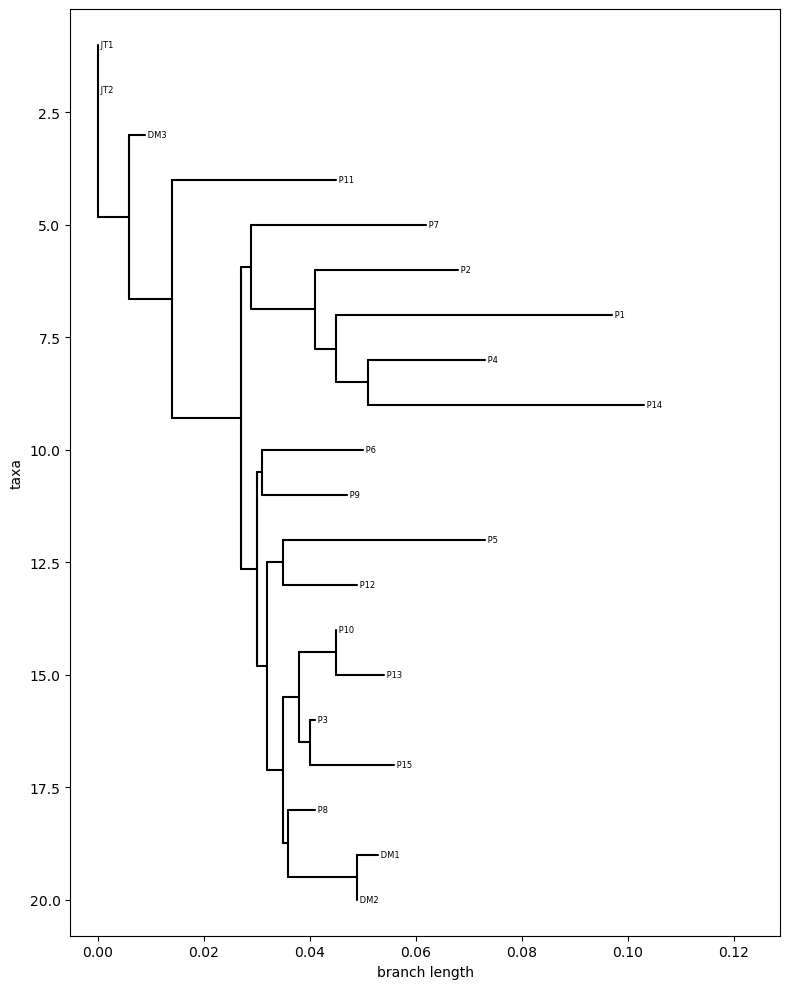

In [10]:
if __name__ == "__main__":
    # Read HIV RT sequences
    sequences = read_fasta("data/lafayette_SARS_RT.fasta")
    
    # Build distance matrix using Smith-Waterman
    dist_matrix, seq_ids = build_distance_matrix(sequences)
    
    # Generate unrooted tree using Neighbor-Joining
    tree = neighbor_joining(dist_matrix, seq_ids)
    
    # Plot tree
    plot_tree(tree)

In [11]:
tree

'(JT1:0.0,JT2:0.0,(DM3:0.003,(P11:0.031,((P7:0.033,(P2:0.027,(P1:0.052,(P4:0.022,P14:0.052):0.006):0.004):0.012):0.002,((P6:0.019,P9:0.016):0.001,((P5:0.038,P12:0.014):0.003,(((P10:0.0,P13:0.009):0.007,(P3:0.001,P15:0.016):0.002):0.003,(P8:0.005,(DM1:0.004,DM2:-0.0):0.013):0.001):0.003):0.002):0.003):0.013):0.008):0.006);'